# Motor C (v2): Forecast Dietario con LightGBM — Modelo Global con Lag Features

**Aguacate Team · TFM La Dieta de un País**

## Estrategia

A diferencia del notebook `05_forecast_series_temporales.ipynb` (Prophet local, 210 modelos independientes),  
este notebook entrena **un único modelo LightGBM global** sobre todas las series combinadas.

| | Prophet (nb05) | LightGBM Global (nb05b) |
|---|---|---|
| Modelos | 210 (1 por país × macro) | 1 global |
| Datos de entrenamiento | ~13 obs por modelo | ~2100 obs totales |
| Features | tendencia + changepoints | lags temporales + contexto país |
| Intervalos de confianza | nativos (Bayesianos) | quantile regression (q=0.10, q=0.90) |
| Forecast | directo | recursivo (cada predicción alimenta el siguiente lag) |

**Hipótesis:** el modelo global captura patrones transversales entre países y macrocategorías  
que los modelos locales de Prophet no pueden ver. La ventaja es especialmente relevante  
para tendencias compartidas (p.ej., aumento global de azúcares, reducción de cereales en economías emergentes).

**Limitación documentada (L8):** forecast recursivo acumula error — las predicciones de años lejanos (2029-2030)  
dependen de las predicciones intermedias, no de datos reales.

In [1]:
import pandas as pd
import numpy as np
import joblib
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder

SEED = 42
np.random.seed(SEED)

MACROS = [
    'pct_Cereales', 'pct_Tuberculos', 'pct_Azucares',
    'pct_Aceites_Grasas', 'pct_Carnes', 'pct_Lacteos_Huevos', 'pct_Frutas_Verduras'
]
FEATURES_LGB_FINAL = MACROS + ['log_Food_CPI', 'cluster_id']
HORIZON_YEAR = 2030
N_LAGS = 3  # lag1, lag2, lag3

MACRO_COLORS = {
    'pct_Cereales':       '#f0a500',
    'pct_Tuberculos':     '#8b4513',
    'pct_Azucares':       '#e84393',
    'pct_Aceites_Grasas': '#ffd700',
    'pct_Carnes':         '#c0392b',
    'pct_Lacteos_Huevos': '#a0a0a0',
    'pct_Frutas_Verduras':'#2ecc71'
}

print(f'LightGBM version: {lgb.__version__}')
print('Librerías cargadas')

LightGBM version: 4.6.0
Librerías cargadas


In [2]:
# ── CARGA DE DATOS ───────────────────────────────────────────────
df = pd.read_parquet('../processed/03_clusters.parquet')
lgb_co2_model = joblib.load('../processed/lgb_final.pkl')

# Encoder para país (feature categórica)
le_country = LabelEncoder()
df['country_enc'] = le_country.fit_transform(df['Area'])

# Encoder para macrocategoría
le_macro = LabelEncoder()

print(f'Dataset: {df.shape}')
print(f'Países: {df["Area"].nunique()} | Años: {df["Year"].min()}–{df["Year"].max()}')
print(f'Modelo CO₂ LightGBM cargado: {type(lgb_co2_model).__name__}')

Dataset: (390, 16)
Países: 30 | Años: 2010–2022
Modelo CO₂ LightGBM cargado: LGBMRegressor


In [3]:
# ── CONSTRUCCIÓN DEL DATASET DE ENTRENAMIENTO ────────────────────
# Estrategia: formato largo + lag features
# Una fila = (país, macro, año_t) con target = valor en año_t
# Features: lag1=año_(t-1), lag2=año_(t-2), lag3=año_(t-3) + contexto

def build_lag_dataset(df, macros, n_lags=3):
    records = []
    for country in df['Area'].unique():
        sub = df[df['Area'] == country].sort_values('Year').reset_index(drop=True)
        country_enc = sub['country_enc'].iloc[0]
        cluster_id  = sub['cluster_id'].iloc[-1]
        log_cpi     = np.log(sub['Food_CPI'].iloc[-1])  # último valor

        for macro in macros:
            macro_enc = le_macro.fit_transform(macros).tolist().index(
                le_macro.transform([macro])[0] if macro in le_macro.classes_ else 0
            )
            values = sub[macro].values  # 13 valores temporales
            years  = sub['Year'].values

            for i in range(n_lags, len(values)):
                row = {
                    'Area':        country,
                    'country_enc': country_enc,
                    'macro':       macro,
                    'year':        years[i],
                    'cluster_id':  cluster_id,
                    'log_Food_CPI':log_cpi,
                    'target':      values[i],
                }
                for lag in range(1, n_lags + 1):
                    row[f'lag{lag}'] = values[i - lag]
                records.append(row)

    return pd.DataFrame(records)

# Encodear macros antes de llamar a la función
le_macro.fit(MACROS)

train_df = build_lag_dataset(df, MACROS, n_lags=N_LAGS)
train_df['macro_enc'] = le_macro.transform(train_df['macro'])

print(f'Dataset entrenamiento: {train_df.shape}')
print(f'Filas por macro (media): {len(train_df) / len(MACROS):.0f}')
print(f'Distribución por macro:')
print(train_df['macro'].value_counts())

Dataset entrenamiento: (2100, 11)
Filas por macro (media): 300
Distribución por macro:
macro
pct_Cereales           300
pct_Tuberculos         300
pct_Azucares           300
pct_Aceites_Grasas     300
pct_Carnes             300
pct_Lacteos_Huevos     300
pct_Frutas_Verduras    300
Name: count, dtype: int64


In [4]:
# ── FEATURES Y TARGET ────────────────────────────────────────────
FEAT_COLS = [f'lag{i}' for i in range(1, N_LAGS + 1)] + [
    'year', 'macro_enc', 'country_enc', 'cluster_id', 'log_Food_CPI'
]
TARGET_COL = 'target'

X_train = train_df[FEAT_COLS].values
y_train = train_df[TARGET_COL].values

print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'Features: {FEAT_COLS}')
print(f'Target range: {y_train.min():.4f} – {y_train.max():.4f}')

X_train: (2100, 8)
y_train: (2100,)
Features: ['lag1', 'lag2', 'lag3', 'year', 'macro_enc', 'country_enc', 'cluster_id', 'log_Food_CPI']
Target range: 0.0097 – 0.7667


In [5]:
# ── VALIDACIÓN CRUZADA — MODELO MEDIO ────────────────────────────
# Walk-forward validation: entrenamos en t=2013..2019, validamos en t=2020..2022
# (simulando que predecimos los últimos 3 años conocidos)

train_mask = train_df['year'] <= 2019
val_mask   = train_df['year'] >= 2020

X_wf_train = train_df.loc[train_mask, FEAT_COLS].values
y_wf_train = train_df.loc[train_mask, TARGET_COL].values
X_wf_val   = train_df.loc[val_mask, FEAT_COLS].values
y_wf_val   = train_df.loc[val_mask, TARGET_COL].values

PARAMS_FORECAST = {
    'n_estimators': 400,
    'learning_rate': 0.05,
    'max_depth': 5,
    'num_leaves': 20,
    'min_child_samples': 10,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': SEED,
    'verbose': -1
}

lgb_forecast_wf = lgb.LGBMRegressor(**PARAMS_FORECAST)
lgb_forecast_wf.fit(X_wf_train, y_wf_train)

y_val_pred = lgb_forecast_wf.predict(X_wf_val)

mae_wf  = mean_absolute_error(y_wf_val, y_val_pred)
r2_wf   = r2_score(y_wf_val, y_val_pred)
rmse_wf = np.sqrt(mean_squared_error(y_wf_val, y_val_pred))

print('WALK-FORWARD VALIDATION (train ≤2019, val 2020–2022):')
print(f'  R²   = {r2_wf:.4f}')
print(f'  MAE  = {mae_wf:.6f} (proporción calórica)')
print(f'  RMSE = {rmse_wf:.6f}')
print(f'  Muestras val: {len(y_wf_val)}')

WALK-FORWARD VALIDATION (train ≤2019, val 2020–2022):
  R²   = 0.9943
  MAE  = 0.006372 (proporción calórica)
  RMSE = 0.010219
  Muestras val: 630


In [6]:
# ── MODELOS FINALES: MEDIA + CUANTILES ───────────────────────────
# Modelo medio (yhat)
lgb_forecast_mean = lgb.LGBMRegressor(**PARAMS_FORECAST)
lgb_forecast_mean.fit(X_train, y_train)

# Modelo cuantil inferior q=0.10 (IC 80% inferior)
params_q_low = {**PARAMS_FORECAST, 'objective': 'quantile', 'alpha': 0.10}
lgb_forecast_low = lgb.LGBMRegressor(**params_q_low)
lgb_forecast_low.fit(X_train, y_train)

# Modelo cuantil superior q=0.90 (IC 80% superior)
params_q_high = {**PARAMS_FORECAST, 'objective': 'quantile', 'alpha': 0.90}
lgb_forecast_high = lgb.LGBMRegressor(**params_q_high)
lgb_forecast_high.fit(X_train, y_train)

print('Modelos entrenados:')
print('  ✅ lgb_forecast_mean  (predicción central)')
print('  ✅ lgb_forecast_low   (cuantil 10% — límite inferior IC 80%)')
print('  ✅ lgb_forecast_high  (cuantil 90% — límite superior IC 80%)')

Modelos entrenados:
  ✅ lgb_forecast_mean  (predicción central)
  ✅ lgb_forecast_low   (cuantil 10% — límite inferior IC 80%)
  ✅ lgb_forecast_high  (cuantil 90% — límite superior IC 80%)


In [7]:
# ── FORECAST RECURSIVO 2023–2030 ─────────────────────────────────
# Para cada país × macro: usamos los últimos N_LAGS valores conocidos
# y predecimos año a año, alimentando cada predicción como nuevo lag.

def recursive_forecast(df_hist, country, macro, models, n_lags, horizon_year):
    """
    Genera forecast recursivo para un país × macrocategoría.
    models = (mean_model, low_model, high_model)
    """
    m_mean, m_low, m_high = models
    sub = df_hist[df_hist['Area'] == country].sort_values('Year')

    country_enc = sub['country_enc'].iloc[0]
    cluster_id  = sub['cluster_id'].iloc[-1]
    log_cpi     = np.log(sub['Food_CPI'].iloc[-1])
    macro_enc   = le_macro.transform([macro])[0]

    # Buffer de lags: valores históricos reales al inicio
    lag_buffer = list(sub[macro].values[-n_lags:])  # últimos N_LAGS valores reales

    results = []
    for year in range(2023, horizon_year + 1):
        feat = np.array([[
            lag_buffer[-1],  # lag1
            lag_buffer[-2],  # lag2
            lag_buffer[-3],  # lag3
            year,
            macro_enc,
            country_enc,
            cluster_id,
            log_cpi
        ]])

        yhat       = float(m_mean.predict(feat)[0])
        yhat_lower = float(m_low.predict(feat)[0])
        yhat_upper = float(m_high.predict(feat)[0])

        # Clamp 0-1
        yhat       = np.clip(yhat, 0, 1)
        yhat_lower = np.clip(yhat_lower, 0, 1)
        yhat_upper = np.clip(yhat_upper, 0, 1)

        results.append({
            'Area': country, 'variable': macro, 'Year': year,
            'yhat': yhat, 'yhat_lower': yhat_lower, 'yhat_upper': yhat_upper
        })

        # Actualizar buffer con la predicción central (forecast recursivo)
        lag_buffer.append(yhat)

    return results


models_tuple = (lgb_forecast_mean, lgb_forecast_low, lgb_forecast_high)

forecast_records = []
countries = sorted(df['country_enc'].drop_duplicates().index.map(
    lambda i: df.loc[i, 'Area']
) if False else df['Area'].unique())

for i, country in enumerate(countries):
    for macro in MACROS:
        rows = recursive_forecast(df, country, macro, models_tuple, N_LAGS, HORIZON_YEAR)
        forecast_records.extend(rows)
    if (i + 1) % 10 == 0:
        print(f'  {i+1}/{len(countries)} países procesados...')

forecast_df = pd.DataFrame(forecast_records)

# Añadir años históricos (2010–2022) en formato largo para el dataset final
hist_long = df.melt(
    id_vars=['Area', 'Year'],
    value_vars=MACROS,
    var_name='variable',
    value_name='yhat'
)
hist_long['yhat_lower'] = hist_long['yhat']
hist_long['yhat_upper'] = hist_long['yhat']

full_df = pd.concat([hist_long, forecast_df], ignore_index=True)
full_df = full_df.sort_values(['Area', 'variable', 'Year']).reset_index(drop=True)

print(f'\nForecast shape (solo 2023-2030): {forecast_df.shape}')
print(f'Dataset completo (2010-2030): {full_df.shape}')

  10/30 países procesados...
  20/30 países procesados...
  30/30 países procesados...

Forecast shape (solo 2023-2030): (1680, 6)
Dataset completo (2010-2030): (4410, 6)


In [8]:
# ── CONSTRUIR VECTORES DIETARIOS Y PREDECIR CO₂ ─────────────────
pivot = forecast_df.pivot_table(
    index=['Area', 'Year'],
    columns='variable',
    values='yhat'
).reset_index()
pivot.columns.name = None

last_cluster = df.groupby('Area')['cluster_id'].last().reset_index()
pivot = pivot.merge(last_cluster, on='Area', how='left')

last_cpi = df.groupby('Area')['Food_CPI'].last().reset_index()
last_cpi['log_Food_CPI'] = np.log(last_cpi['Food_CPI'])
pivot = pivot.merge(last_cpi[['Area', 'log_Food_CPI']], on='Area', how='left')

# Re-normalizar a suma 1 (constraint composicional)
row_sums = pivot[MACROS].sum(axis=1)
pivot[MACROS] = pivot[MACROS].div(row_sums, axis=0)

pivot['CO2eq_forecast'] = lgb_co2_model.predict(pivot[FEATURES_LGB_FINAL]).astype('float32')

print(f'Pivot shape: {pivot.shape}')
print(f'CO2 proyectado — rango: {pivot["CO2eq_forecast"].min():.2f} – {pivot["CO2eq_forecast"].max():.2f} t/cápita')
print(f'\nTop 5 CO2 proyectado 2030:')
print(pivot[pivot['Year'] == 2030][['Area', 'CO2eq_forecast']].sort_values('CO2eq_forecast', ascending=False).head())

Pivot shape: (240, 12)
CO2 proyectado — rango: 0.81 – 9.03 t/cápita

Top 5 CO2 proyectado 2030:
          Area  CO2eq_forecast
31      Brazil        8.344073
15   Australia        6.669749
7    Argentina        6.239921
39      Canada        5.787984
167     Poland        4.394745


In [9]:
# ── GUARDAR PARQUET ──────────────────────────────────────────────
co2_fc = pivot[['Area', 'Year', 'CO2eq_forecast']]
output = full_df.merge(co2_fc, on=['Area', 'Year'], how='left')

# Guardar con sufijo _lgbm para diferenciar del Prophet
output.to_parquet('../processed/05b_forecast_lgbm.parquet', index=False)
print(f'Guardado: processed/05b_forecast_lgbm.parquet')
print(f'Shape: {output.shape}')
print(f'Columnas: {output.columns.tolist()}')

Guardado: processed/05b_forecast_lgbm.parquet
Shape: (4410, 7)
Columnas: ['Area', 'Year', 'variable', 'yhat', 'yhat_lower', 'yhat_upper', 'CO2eq_forecast']


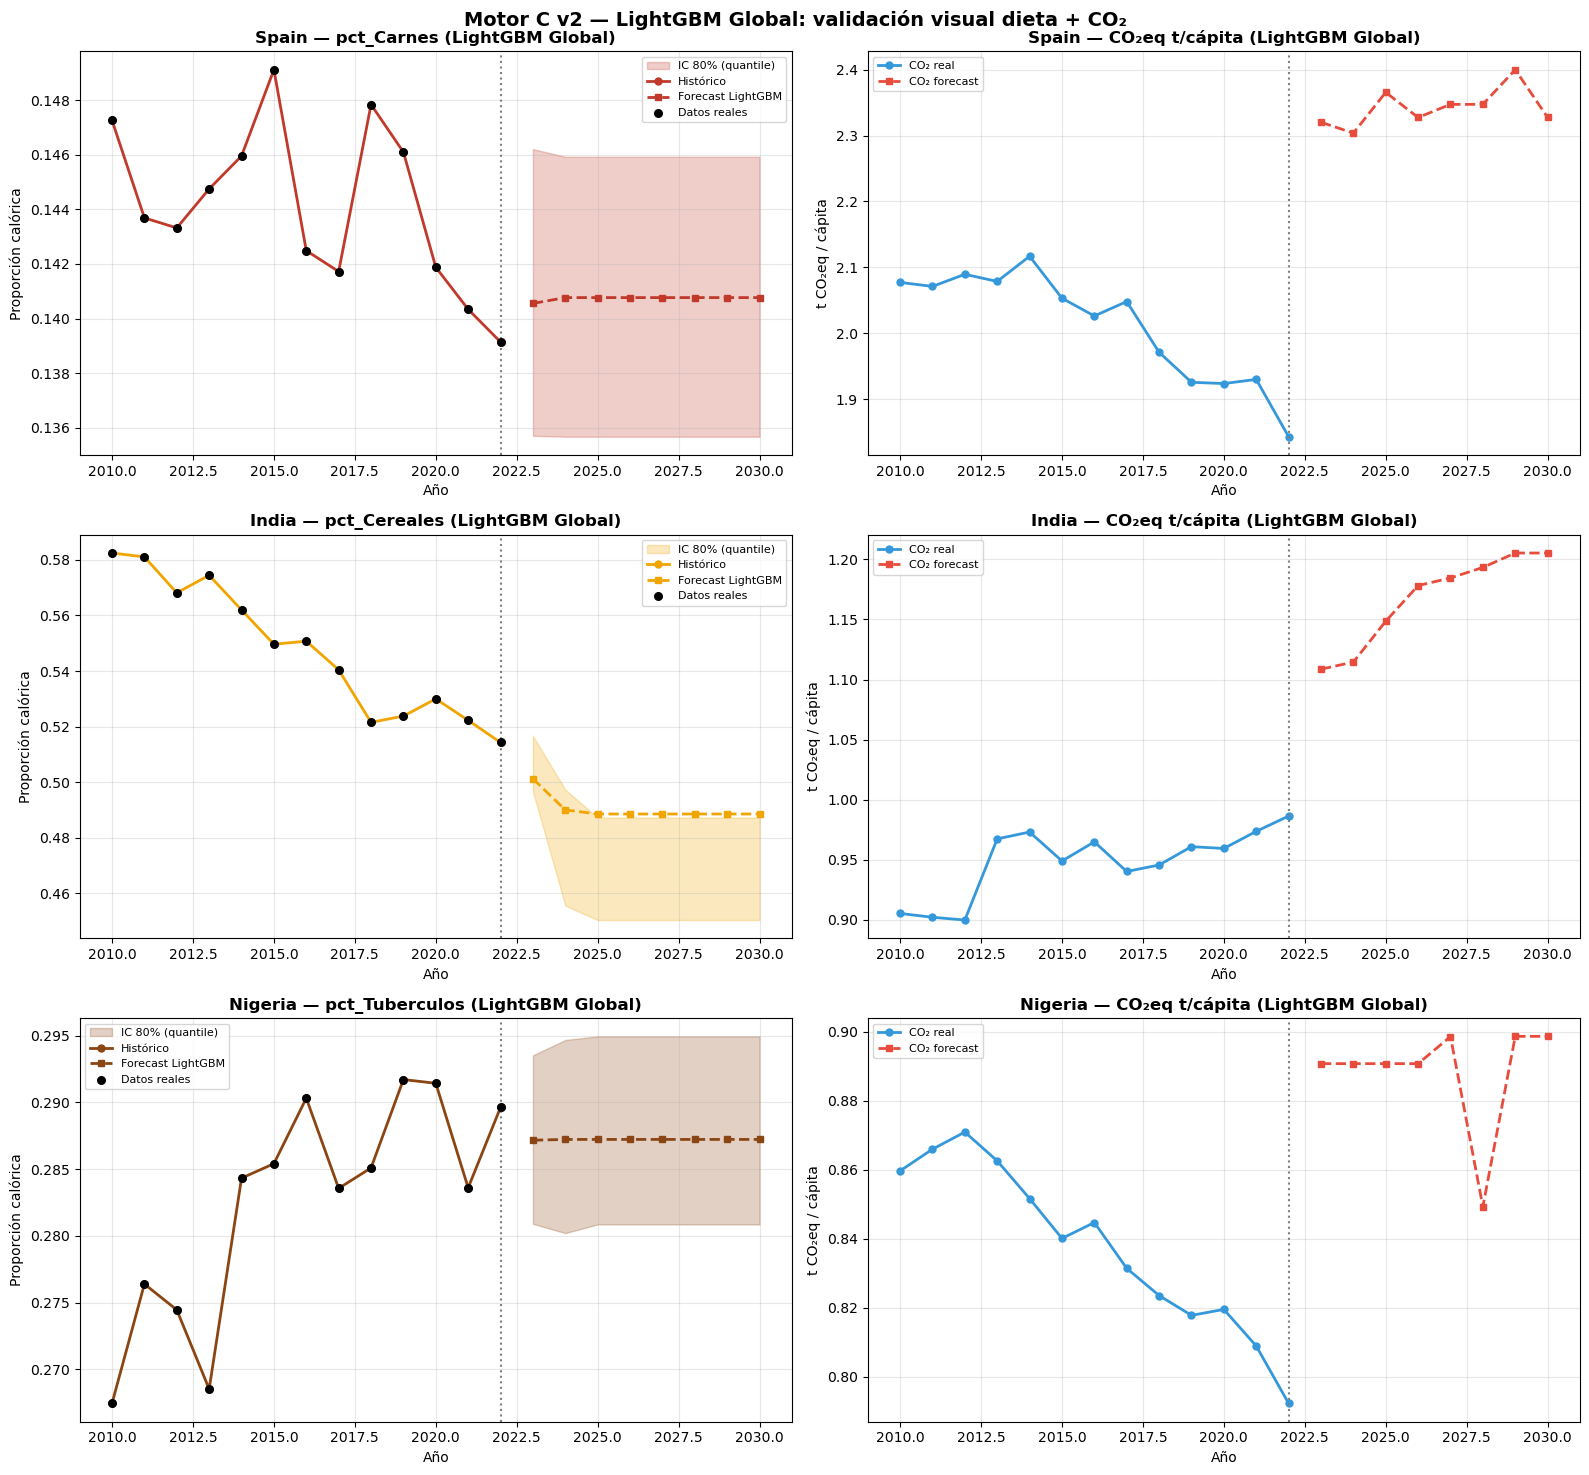

Guardado: processed/05b_forecast_lgbm_validacion.png


In [10]:
# ── VALIDACIÓN VISUAL ─────────────────────────────────────────────
VALID_COUNTRIES = ['Spain', 'India', 'Nigeria']

fig, axes = plt.subplots(len(VALID_COUNTRIES), 2, figsize=(16, 5 * len(VALID_COUNTRIES)))

for row, country in enumerate(VALID_COUNTRIES):
    macro_plot = 'pct_Carnes' if country == 'Spain' else 'pct_Cereales' if country == 'India' else 'pct_Tuberculos'

    fc_country = output[(output['Area'] == country) & (output['variable'] == macro_plot)].sort_values('Year')
    hist_country = df[df['Area'] == country].sort_values('Year')

    ax = axes[row, 0]
    ax.fill_between(
        fc_country[fc_country['Year'] > 2022]['Year'],
        fc_country[fc_country['Year'] > 2022]['yhat_lower'],
        fc_country[fc_country['Year'] > 2022]['yhat_upper'],
        alpha=0.25, color=MACRO_COLORS[macro_plot], label='IC 80% (quantile)'
    )
    ax.plot(fc_country[fc_country['Year'] <= 2022]['Year'],
            fc_country[fc_country['Year'] <= 2022]['yhat'],
            '-o', color=MACRO_COLORS[macro_plot], lw=2, ms=5, label='Histórico')
    ax.plot(fc_country[fc_country['Year'] > 2022]['Year'],
            fc_country[fc_country['Year'] > 2022]['yhat'],
            '--s', color=MACRO_COLORS[macro_plot], lw=2, ms=5, label='Forecast LightGBM')
    ax.scatter(hist_country['Year'], hist_country[macro_plot],
               color='black', zorder=5, s=30, label='Datos reales')
    ax.axvline(2022, color='gray', linestyle=':', lw=1.5)
    ax.set_title(f'{country} — {macro_plot} (LightGBM Global)', fontweight='bold')
    ax.set_xlabel('Año'); ax.set_ylabel('Proporción calórica')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # CO₂
    co2_hist = hist_country[['Year', 'CO2eq_t_per_capita']]
    co2_proj = pivot[(pivot['Area'] == country)][['Year', 'CO2eq_forecast']]

    ax2 = axes[row, 1]
    ax2.plot(co2_hist['Year'], co2_hist['CO2eq_t_per_capita'],
             '-o', color='#3498db', lw=2, ms=5, label='CO₂ real')
    ax2.plot(co2_proj[co2_proj['Year'] > 2022]['Year'],
             co2_proj[co2_proj['Year'] > 2022]['CO2eq_forecast'],
             '--s', color='#e74c3c', lw=2, ms=5, label='CO₂ forecast')
    ax2.axvline(2022, color='gray', linestyle=':', lw=1.5)
    ax2.set_title(f'{country} — CO₂eq t/cápita (LightGBM Global)', fontweight='bold')
    ax2.set_xlabel('Año'); ax2.set_ylabel('t CO₂eq / cápita')
    ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.suptitle('Motor C v2 — LightGBM Global: validación visual dieta + CO₂',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../processed/05b_forecast_lgbm_validacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: processed/05b_forecast_lgbm_validacion.png')

In [11]:
# ── TABLA COMPARATIVA CO₂ 2022 vs 2030 ───────────────────────────
co2_2022 = df[df['Year'] == 2022][['Area', 'CO2eq_t_per_capita']].rename(
    columns={'CO2eq_t_per_capita': 'CO2_2022'})
co2_2030 = pivot[pivot['Year'] == 2030][['Area', 'CO2eq_forecast']].rename(
    columns={'CO2eq_forecast': 'CO2_2030_lgbm'})

resumen = co2_2022.merge(co2_2030, on='Area')
resumen['Delta_pct'] = ((resumen['CO2_2030_lgbm'] - resumen['CO2_2022']) / resumen['CO2_2022'] * 100).round(1)
resumen = resumen.sort_values('Delta_pct')

print('CO₂ proyectado 2030 vs observado 2022 (LightGBM Global):')
print(resumen.to_string(index=False))

CO₂ proyectado 2030 vs observado 2022 (LightGBM Global):
                                                Area  CO2_2022  CO2_2030_lgbm  Delta_pct
                                            Ethiopia  1.217610       0.881930 -27.600000
                                              Canada  7.434406       5.787984 -22.100000
                                            Thailand  3.268874       2.613988 -20.000000
                                              Brazil  9.748733       8.344073 -14.400000
                                           Australia  7.687373       6.669749 -13.200000
                                             Romania  2.986566       2.614038 -12.500000
                                             Senegal  1.184145       1.056655 -10.800000
                                        Saudi Arabia  2.354669       2.125564  -9.700000
United Kingdom of Great Britain and Northern Ireland  1.858086       1.690758  -9.000000
                                          Kazakhstan 

Feature importances (LightGBM Global Forecast):
lag1            948
country_enc     521
lag2            483
lag3            482
macro_enc       256
log_Food_CPI    222
year            128
cluster_id       26
dtype: int32


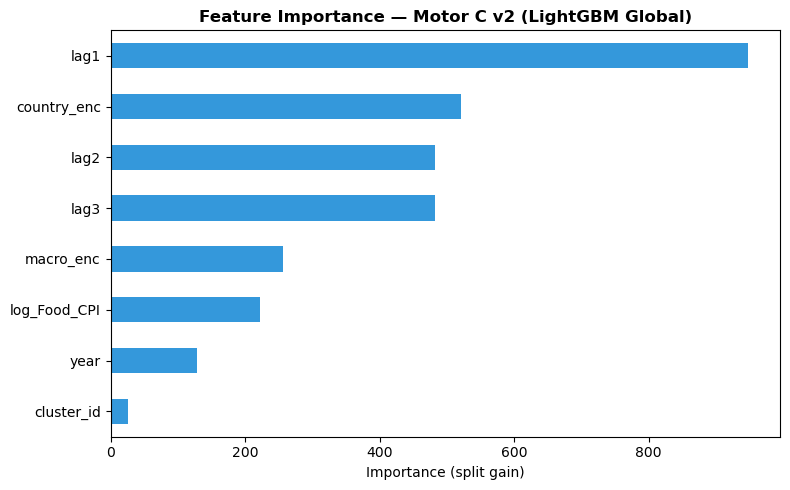

Guardado: processed/05b_feature_importance.png


In [12]:
# ── IMPORTANCIA DE FEATURES ──────────────────────────────────────
feat_imp = pd.Series(
    lgb_forecast_mean.feature_importances_,
    index=FEAT_COLS
).sort_values(ascending=False)

print('Feature importances (LightGBM Global Forecast):')
print(feat_imp.round(1))

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax, color='#3498db')
ax.invert_yaxis()
ax.set_title('Feature Importance — Motor C v2 (LightGBM Global)', fontweight='bold')
ax.set_xlabel('Importance (split gain)')
plt.tight_layout()
plt.savefig('../processed/05b_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: processed/05b_feature_importance.png')

In [13]:
# ── RESUMEN EJECUTIVO ─────────────────────────────────────────────
print('=' * 60)
print('RESUMEN EJECUTIVO — MOTOR C v2 (LightGBM Global)')
print('Aguacate Team · TFM La Dieta de un País')
print('=' * 60)
print()
print('CONFIGURACIÓN:')
print(f'  Modelos entrenados: 3 (mean + q10 + q90)')
print(f'  Features: {FEAT_COLS}')
print(f'  Lags: {N_LAGS} | Muestras entrenamiento: {X_train.shape[0]}')
print()
print('MÉTRICAS WALK-FORWARD (val 2020-2022):')
print(f'  R²   = {r2_wf:.4f}')
print(f'  MAE  = {mae_wf:.6f} (proporción calórica)')
print(f'  RMSE = {rmse_wf:.6f}')
print()
print('OUTPUTS:')
print('  processed/05b_forecast_lgbm.parquet')
print('  processed/05b_forecast_lgbm_validacion.png')
print('  processed/05b_feature_importance.png')

RESUMEN EJECUTIVO — MOTOR C v2 (LightGBM Global)
Aguacate Team · TFM La Dieta de un País

CONFIGURACIÓN:
  Modelos entrenados: 3 (mean + q10 + q90)
  Features: ['lag1', 'lag2', 'lag3', 'year', 'macro_enc', 'country_enc', 'cluster_id', 'log_Food_CPI']
  Lags: 3 | Muestras entrenamiento: 2100

MÉTRICAS WALK-FORWARD (val 2020-2022):
  R²   = 0.9943
  MAE  = 0.006372 (proporción calórica)
  RMSE = 0.010219

OUTPUTS:
  processed/05b_forecast_lgbm.parquet
  processed/05b_forecast_lgbm_validacion.png
  processed/05b_feature_importance.png


## Próximo paso: comparación con Prophet (nb05)

Comparar visualmente los forecasts de ambos notebooks para los mismos países y macrocategorías.
Criterios de decisión:

| Criterio | Favorable a Prophet | Favorable a LightGBM Global |
|---|---|---|
| MAE walk-forward | si LGB R² < 0.6 | si LGB R² > 0.7 |
| Coherencia tendencial | si Prophet sigue mejor la inercia visual | si LGB captura mejor los quiebres |
| Amplitud IC | si LGB IC es más estrecho y creíble | si Prophet IC son demasiado amplios |
| Interpretabilidad | Prophet: narrativa tendencia | LGB: feature importance lag1 dominante = inercia |

**Decisión final documentada en memoria v1.5**